In [ ]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Project Context

## Business Question

What drives checkout abandonment, and how can we identify high-intent users before they leave?

## Notebook Objective

Before conducting product analytics and predictive modeling, we first need to understand the dataset.

This notebook focuses on:

- understanding the event-level dataset
- understanding the session-level dataset
- validating data quality
- exploring the basic characteristics of the data
- confirming that the dataset is ready for further analysis

# 2. Import Libraries

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

from src.services import (
    load_dataset_overview,
    load_event_distribution,
    load_device_distribution,
    load_source_distribution,
    load_country_distribution,
    load_session_summary,
    load_purchase_distribution,
    load_checkout_distribution,
    load_session_duration,
    load_total_events,
    load_pageviews,
    load_missing_summary,
    load_duplicate_summary,
    load_sessions
)

# 3. Dataset Overview

This section summarizes the size and coverage of the dataset.

## 3.1 Dataset Overview

In [33]:
overview = load_dataset_overview()
summary = pd.DataFrame({
    "Metric": [
        "Total Events",
        "Total Users",
        "Total Sessions",
        "Date Range"
    ],
    "Value": [
        f"{overview.loc[0, 'total_events']:,}",
        f"{overview.loc[0, 'total_users']:,}",
        f"{overview.loc[0, 'total_sessions']:,}",
        f"{overview.loc[0, 'start_date']} to {overview.loc[0, 'end_date']}"
    ]
})

summary

,Metric,Value
0,Total Events,"4,295,584"
1,Total Users,"270,154"
2,Total Sessions,"349,545"
3,Date Range,2020-11-01 to 2021-01-31


### Dataset Summary

The dataset contains **4,295,584 events** generated by **270,154 users** across **349,545 sessions** between **November 1, 2020** and **January 31, 2021**.

With approximately **three months of user interaction data**, the dataset provides comprehensive coverage of the customer journey, from initial visits to completed purchases. The large volume of events and sessions makes it suitable for product analytics, user behavior analysis, funnel analysis, checkout abandonment analysis, and purchase intent prediction in the subsequent stages of this project.

## 3.2 Session Overview

In [38]:
session_summary = load_session_summary()

session_summary

,total_sessions,avg_session_duration,avg_events,avg_pageviews,avg_item_views
0,349545,1077.914357,12.289073,3.863388,1.104487


In [39]:
session = load_sessions()
session.info()

<class 'pandas.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   ga_session_id          349545 non-null  Int64              
 1   user_pseudo_id         349545 non-null  str                
 2   session_start          349545 non-null  datetime64[us, UTC]
 3   session_end            349545 non-null  datetime64[us, UTC]
 4   session_duration_sec   349545 non-null  Int64              
 5   total_events           349545 non-null  Int64              
 6   unique_pages           349545 non-null  Int64              
 7   pageviews              349545 non-null  Int64              
 8   item_views             349545 non-null  Int64              
 9   searches               349545 non-null  Int64              
 10  add_to_cart            349545 non-null  Int64              
 11  begin_checkout         349545 non-null  Int64     

### Session Summary

To support user-level behavioral analysis, raw GA4 event data was aggregated into **349,545 sessions**. Each session represents a complete sequence of user interactions during a single visit.

On average, a session lasts **1,077.9 seconds**, contains **12.29 events**, generates **3.86 page views**, and includes **1.10 product views**. These session-level metrics provide a comprehensive representation of user engagement and will serve as the foundation for funnel analysis, checkout abandonment analysis, and purchase intent prediction in the following notebooks.

# 4. Data Quality Assessment

## 4.1 Missing Values

In [32]:
missing = load_missing_summary()

missing

,total_rows,missing_user,missing_session,missing_event
0,4295584,0,0,0


### Data Quality Assessment

The event-level dataset contains **no missing values** in the key identifiers, including **user ID**, **session ID**, and **event name**.

Since these fields are essential for sessionization and behavioral analysis, the absence of missing values ensures that user journeys can be accurately reconstructed without requiring additional data cleaning.

## 4.2 Duplicate Session

In [40]:
duplicate = load_duplicate_summary()

duplicate

,total_rows,unique_sessions
0,349545,349545


### Duplicate Check

The session-level dataset contains **349,545 unique sessions**, matching the total number of session records. No duplicate sessions were identified.

This confirms that each row represents a unique user session, ensuring the reliability of subsequent funnel analysis and predictive modeling.

## 4.3 Data Cleaning Summary

### Data Cleaning Summary

The dataset passed all essential data quality checks before analysis:

- ✅ No missing values in key identifiers
- ✅ No duplicate session records
- ✅ Session-level dataset successfully validated
- ✅ Data is ready for exploratory analysis and downstream modeling

# 5. Exploratory Data Analysis
## 5.1 Event Distribution

In [41]:
event_distribution = load_event_distribution()

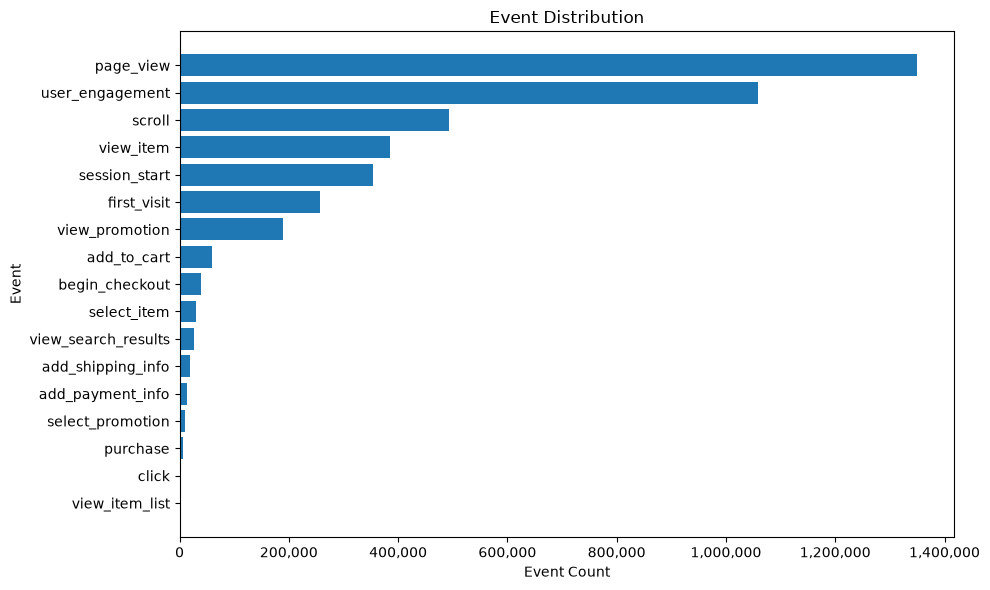

In [45]:
event = event_distribution.sort_values("event_count", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(event["event_name"], event["event_count"])

plt.title("Event Distribution")
plt.xlabel("Event Count")
plt.ylabel("Event")

ax = plt.gca()
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### Insight

The distribution of user events shows that **page_view** and **user_engagement** are the most frequent interactions, indicating that browsing activities dominate user behavior.

As users progress through the shopping journey, event frequencies decrease substantially from **view_item** to **add_to_cart**, **begin_checkout**, and ultimately **purchase**, reflecting a typical e-commerce conversion funnel.

The relatively low number of purchase events compared with browsing events suggests considerable user drop-off during the decision-making process, highlighting opportunities for further funnel and checkout abandonment analysis.

> **Note:** This visualization is based on **event counts** rather than unique users or sessions. Therefore, higher values indicate greater interaction frequency and should not be interpreted as a larger user population.

## 5.2 Device Distribution

In [46]:
device = load_device_distribution()

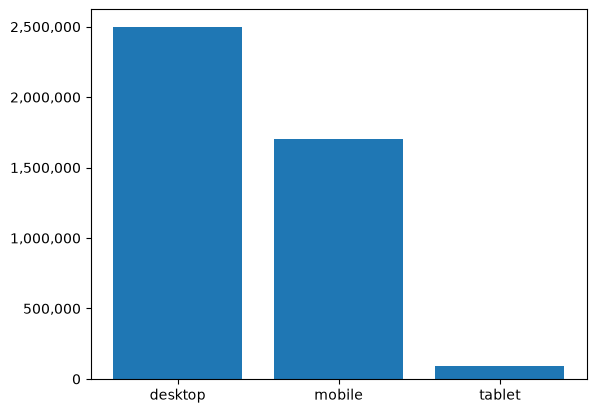

In [48]:
plt.bar(
    device.device_category,
    device.events
)

ax = plt.gca()
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

### Insight

Desktop devices generate the highest number of user events, accounting for the largest share of overall interactions. Mobile devices also contribute a substantial proportion of activity, while tablet usage remains relatively limited.

The results suggest that users primarily interact with the platform through desktop and mobile devices. Consequently, future product optimization and experimentation should prioritize these two platforms, where improvements are likely to have the greatest business impact.

> **Note:** This visualization is based on **event counts** rather than unique users or sessions. Therefore, higher values indicate greater interaction frequency and should not be interpreted as a larger user population.

## 5.3 Acquisition Channel Distribution

In [50]:
source = load_source_distribution()
source

,acquisition_channel,sessions
0,Google,7557
1,Other,1790
2,Direct,1390
3,Unknown,331
4,Referral,12
5,Newsletter,3
6,YouTube,3
7,Partner,2


### Insight

Google is the dominant acquisition channel, accounting for the majority of user sessions in the dataset. Direct traffic represents the second largest identifiable source, while a considerable number of sessions are grouped under **Other**, suggesting that some traffic sources cannot be precisely classified.

Referral, Newsletter, YouTube, and Partner channels contribute only a small number of sessions, indicating that these acquisition channels currently have limited impact on overall traffic.

These findings suggest that future marketing optimization should primarily focus on the major acquisition channels while further investigating the composition of the **Other** category to improve attribution quality.

> **Note:** This visualization is based on **session-level** data, where each record represents a unique user session.

## 5.4 Country

In [52]:
country = load_country_distribution()
country.head(10)

,country,sessions
0,United States,1910483
1,India,391859
2,Canada,324261
3,United Kingdom,133383
4,France,82514
5,Spain,81713
6,China,76159
7,Taiwan,72484
8,Germany,71673
9,Italy,61258


### Insight

The United States generates the highest volume of user events, accounting for a substantially larger share of interactions than any other country. India and Canada rank second and third, while the United Kingdom, France, Spain, China, Taiwan, Germany, and Italy complete the top ten markets.

User activity is concentrated in a relatively small number of countries, suggesting that engagement is geographically uneven. These findings indicate that product optimization, localization efforts, and marketing campaigns should primarily target the markets with the highest user activity.

> **Note:** This visualization is based on **event counts**, representing the volume of user interactions rather than the number of unique users or sessions.

## 5.5 Purchase Distribution

In [53]:
purchase = load_purchase_distribution()

purchase

,purchased,sessions
0,False,344700
1,True,4845


### Insight

Only **4,845 out of 349,545 sessions** resulted in a completed purchase, corresponding to an overall conversion rate of approximately **1.39%**.

The overwhelming majority of sessions did not lead to a purchase, highlighting the inherent challenge of converting browsing behavior into completed transactions. This low conversion rate is typical for e-commerce platforms and motivates a deeper investigation into user drop-off during the checkout process.

> **Note:** This visualization is based on **session-level** data, where each record represents a unique user session.

## 5.6 Checkout Abandonment

In [54]:
checkout = load_checkout_distribution()
checkout

,checkout_abandoned,sessions
0,False,343299
1,True,6246


### Insight

Among users who initiated the checkout process, **6,246 sessions** ended without completing a purchase, resulting in a **checkout abandonment rate of 56.33%**.

This indicates that more than half of potential purchases are lost during the checkout stage, making it one of the most critical points in the customer journey. Understanding the factors associated with checkout abandonment is therefore essential for improving conversion performance.

> **Note:** This visualization is based on **session-level** data.

# 6. Key Findings

The exploratory analysis reveals several important characteristics of the dataset:

- The dataset contains over **4.29 million events** from **349,545 user sessions**.
- Data quality is high, with no missing values or duplicate sessions in key identifiers.
- User interactions are dominated by browsing activities, while purchase events are relatively rare.
- Desktop devices account for the largest share of interactions.
- Google is the primary acquisition channel.
- User activity is concentrated in a small number of countries.
- Only **1.39%** of sessions result in a purchase.
- More than **56%** of checkout sessions are abandoned, indicating a substantial opportunity to improve conversion.

# 7. Next Steps

The dataset has been validated and is suitable for downstream analysis.

The next notebook will investigate:

- Funnel Analysis
- Checkout Abandonment Analysis
- Purchase Intent Prediction